# Clase 23 — Datos, sesgos y cómo aprende una IA

**Diplomado IA Aplicada al Diseño · UDD · 2026** · Prof. Darío Osorio

Ejecuta las celdas en orden. Donde diga `# TU TURNO`, modifica lo indicado.

## Objetivos del notebook
1. Cargar y explorar un dataset real (reseñas en español).
2. Detectar visualmente balance de clases y valores faltantes.
3. Identificar un sesgo posible.

**Archivos necesarios**: `Clase_23_dataset_resenas_es.csv` (súbelo a Colab junto con este notebook, ver Paso 1).

## Paso 0 — Instalación


In [ ]:
!pip install -q pandas matplotlib seaborn
print("Listo.")

Listo.


## Paso 1 — Subir y cargar el dataset

Este notebook usa un dataset local (`Clase_23_dataset_resenas_es.csv`), preparado por el profesor: 1000+ reseñas de productos en español, con distribución realista (desbalanceada) y algunos valores faltantes / duplicados a propósito, para que los detectes tú.

Antes de ejecutar la siguiente celda: `Archivo → Subir cuaderno` ya lo hiciste; ahora sube también el CSV con el ícono de carpeta (📁) a la izquierda → `Subir a almacenamiento de sesión` → selecciona `Clase_23_dataset_resenas_es.csv`.

In [12]:
import pandas as pd

# Dataset local (no depende de descargas externas ni de conexión inestable en vivo)
df = pd.read_csv("Coffee_ShopS_Sales.csv")

print(f"Cargadas {len(df)} filas")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Cargadas 149116 filas
Columnas disponibles: ['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## Paso 2 — Ver primeras filas

In [14]:
df[['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']].head(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,1/1/2023,7:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,1/1/2023,7:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,1/1/2023,7:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,1/1/2023,7:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,1/1/2023,7:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


## Paso 3 — Balance de clases (¿está equilibrado?)

Cantidad de ventas de productos):
product_category
Bakery                22796
Branded                 747
Coffee                58416
Coffee beans           1753
Drinking Chocolate    11468
Flavours               6790
Loose Tea              1210
Packaged Chocolate      487
Tea                   45449
Name: count, dtype: int64


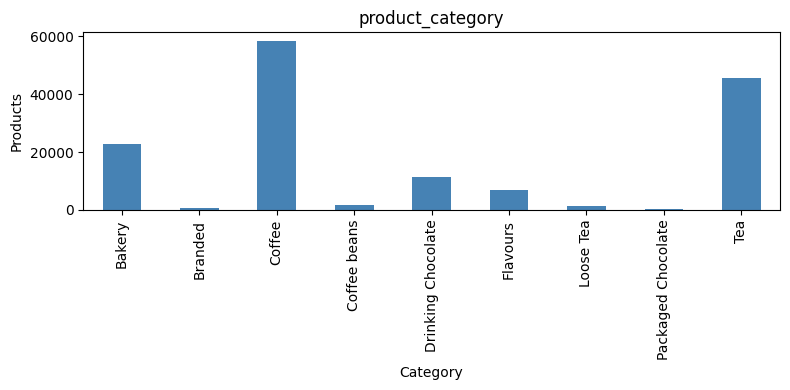


Ratio maxima/minima: 119.95
Hay una alta venta de café y té en el negocioXD


In [18]:
import matplotlib.pyplot as plt

counts = df['product_category'].value_counts().sort_index()
print("Cantidad de ventas de productos):")
print(counts)

plt.figure(figsize=(8,4))
counts.plot(kind='bar', color='steelblue')
plt.title("product_category")
plt.xlabel("Category")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

ratio = counts.max() / counts.min()
print(f"\nRatio maxima/minima: {ratio:.2f}")
if ratio > 2:
    print("Hay una alta venta de café y té en el negocioXD")

## Paso 4 — Longitud de las reseñas por calificación

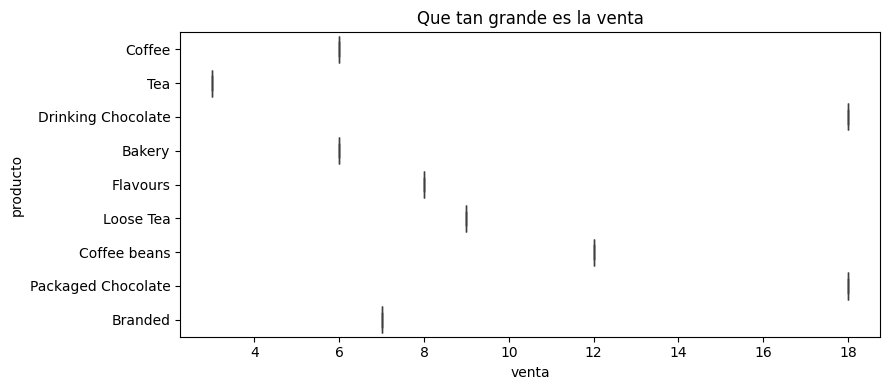

Observa: hay diferencias sistematicas de largo por categoria?
Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.


In [28]:
import seaborn as sns

df['unit_price'] = df['product_category'].str.len()

plt.figure(figsize=(9,4))
sns.boxplot(x='unit_price', y='product_category', data=df)
plt.title("Que tan grande es la venta")
plt.xlabel("venta")
plt.ylabel("producto")
plt.tight_layout()
plt.show()

print("Observa: hay diferencias sistematicas de largo por categoria?")
print("Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.")

## Paso 5 — Valores faltantes

In [ ]:
print("Valores faltantes por columna:\n")
print(df.isnull().sum())
print("\nFilas con texto vacío:", (df['text'].fillna('') == '').sum())
print("\nDuplicados por texto (ignorando el id):", df.duplicated(subset=['text']).sum())

Valores faltantes por columna:

id           0
text         8
stars        0
categoria    0
largo        8
dtype: int64

Filas con texto vacío: 8

Duplicados por texto (ignorando el id): 187


## TU TURNO — bitácora

Anota en la bitácora de tu proyecto:

1. ¿Cuál es la clase más representada? ¿Cuál la menos?
2. ¿Hay patrones de largo del texto que podrían ser un sesgo?
3. ¿Cómo se ve el equilibrio de tu propio dataset comparado con éste?

## Cierre
Guarda copia (`Archivo → Guardar copia en Drive`), descargala y súbela a tu repo en `notebooks/Clase_23.ipynb`.